Data berhasil dibaca
Jumlah data: 364

5 data pertama:
         date       NO2
0  2025-08-12  0.000021
1  2025-08-26  0.000029
2  27-08-2025       NaN
3  2025-08-24       NaN
4  2025-09-10  0.000021

Nama kolom:
['date', 'NO2']

Jumlah data setelah cleaning: 265

Jumlah missing value:
date    0
NO2     0
dtype: int64

HASIL DETEKSI OUTLIER NO2
Jumlah data       : 265
Jumlah data normal: 251
Jumlah outlier    : 14
Persentase outlier: 5.28%

DATA OUTLIER NO2
      date      NO2
2025-09-10 0.000008
2026-01-24 0.000007
2026-02-06 0.000012
2026-02-08 0.000010
2026-03-07 0.000008
2026-05-22 0.000085
2026-06-12 0.000047
2026-07-09 0.000050
2026-07-12 0.000068
2026-07-14 0.000045
2026-07-18 0.000046
2026-07-25 0.000048
2026-07-27 0.000048
2026-08-13 0.000053


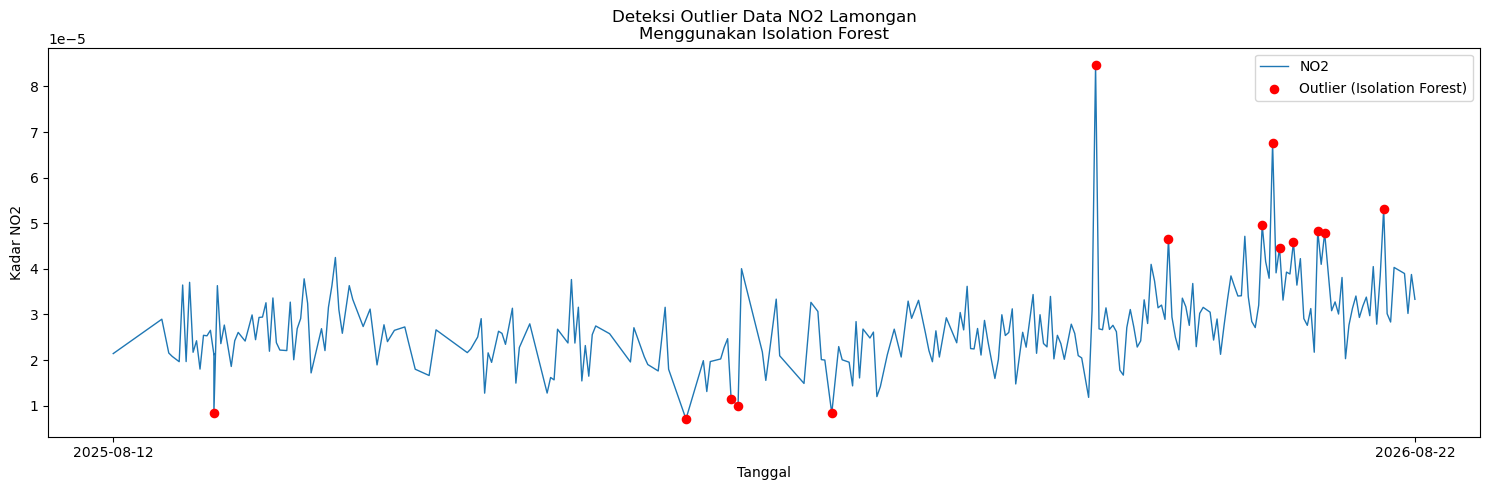

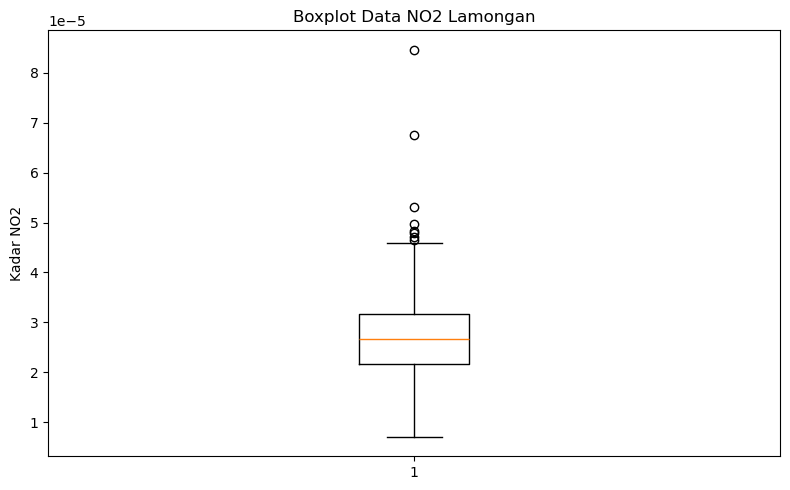

In [7]:
# ============================================================
# DETEKSI OUTLIER DATA NO2 LAMONGAN
# METODE: ISOLATION FOREST
# ============================================================

# ============================================================
# 1. Import Library
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest


# ============================================================
# 2. Membaca Dataset
# ============================================================

df = pd.read_csv("No2_lamongan.csv")

print("Data berhasil dibaca")
print("Jumlah data:", len(df))

print("\n5 data pertama:")
print(df.head())


# ============================================================
# 3. Memeriksa Kolom Dataset
# ============================================================

print("\nNama kolom:")
print(df.columns.tolist())


# ============================================================
# 4. Membersihkan Data
# ============================================================

# Mengubah kolom date menjadi datetime
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Mengubah NO2 menjadi numerik
df["NO2"] = pd.to_numeric(
    df["NO2"],
    errors="coerce"
)

# Menghapus missing value
df_clean = df.dropna(
    subset=["date", "NO2"]
).copy()

# Mengurutkan berdasarkan tanggal
df_clean = df_clean.sort_values(
    "date"
).reset_index(drop=True)

print("\nJumlah data setelah cleaning:",
      len(df_clean))

print("\nJumlah missing value:")
print(
    df_clean[["date", "NO2"]].isnull().sum()
)


# ============================================================
# 5. Isolation Forest
# ============================================================

model_if = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Melakukan deteksi outlier
df_clean["outlier_if"] = model_if.fit_predict(
    df_clean[["NO2"]]
)

#  1  = data normal
# -1  = outlier


# ============================================================
# 6. Memisahkan Data Normal dan Outlier
# ============================================================

data_normal = df_clean[
    df_clean["outlier_if"] == 1
].copy()

outliers_if = df_clean[
    df_clean["outlier_if"] == -1
].copy()


# ============================================================
# 7. Informasi Hasil Deteksi
# ============================================================

print("\n========================================")
print("HASIL DETEKSI OUTLIER NO2")
print("========================================")

print(
    "Jumlah data       :",
    len(df_clean)
)

print(
    "Jumlah data normal:",
    len(data_normal)
)

print(
    "Jumlah outlier    :",
    len(outliers_if)
)

print(
    "Persentase outlier:",
    f"{len(outliers_if) / len(df_clean) * 100:.2f}%"
)


# ============================================================
# 8. Menampilkan Data Outlier
# ============================================================

print("\n========================================")
print("DATA OUTLIER NO2")
print("========================================")

print(
    outliers_if[
        ["date", "NO2"]
    ].to_string(index=False)
)


# ============================================================
# 9. Visualisasi Data dan Outlier
# ============================================================

plt.figure(figsize=(15, 5))

# Data NO2
plt.plot(
    df_clean["date"],
    df_clean["NO2"],
    label="NO2",
    linewidth=1
)

# Data outlier
plt.scatter(
    outliers_if["date"],
    outliers_if["NO2"],
    color="red",
    marker="o",
    s=35,
    label="Outlier (Isolation Forest)",
    zorder=5
)

plt.title(
    "Deteksi Outlier Data NO2 Lamongan\n"
    "Menggunakan Isolation Forest"
)

plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")

plt.legend()

# Menampilkan tanggal awal dan akhir
plt.xticks(
    ticks=[
        df_clean["date"].iloc[0],
        df_clean["date"].iloc[-1]
    ],
    labels=[
        df_clean["date"].iloc[0].strftime("%Y-%m-%d"),
        df_clean["date"].iloc[-1].strftime("%Y-%m-%d")
    ]
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Boxplot NO2
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    df_clean["NO2"],
    vert=True
)

plt.ylabel("Kadar NO2")
plt.title("Boxplot Data NO2 Lamongan")

plt.tight_layout()
plt.show()